In [1]:
import torch
import platform
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from transformers import AutoModelForCausalLM, AutoTokenizer, QuantoConfig

In [5]:
# 모델과 토크나이저 불러오기
model_name = "Qwen/Qwen2.5-1.5B-Instruct"
print("모델을 로드하는 중입니다...")

tokenizer = AutoTokenizer.from_pretrained(model_name)
quant_config = QuantoConfig(weights="int8") # 8비트(INT8) 양자화 설정 객체 생성

# 모델 로드 시 양자화 설정을 주입하여 압축된 상태로 메모리에 올림
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=quant_config,
    device_map="auto"
)

모델을 로드하는 중입니다...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

In [6]:
def visualize_next_tokens(model, tokenizer, text, n=30):
    # 모델 추론 및 확률 계산
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model(**inputs)
        
    next_token_logits = outputs.logits[0, -1, :]
    probabilities = torch.nn.functional.softmax(next_token_logits, dim=-1)
    top_n_probs, top_n_indices = torch.topk(probabilities, n)
    
    # 워드클라우드 생성을 위한 딕셔너리(단어: 확률) 만들기
    token_frequencies = {}
    for i in range(n):
        token_id = top_n_indices[i].item()
        prob = top_n_probs[i].item()
        
        # 특수 토큰을 제외하고 디코딩한 뒤 공백 제거
        token_str = tokenizer.decode([token_id], skip_special_tokens=True).strip()
        
        # 공백, 빈 문자열이 포함된 경우 스킵 (워드클라우드에서 제외)
        if not token_str:
            continue
            
        # 중복되는 단어가 생길 경우 확률 누적
        if token_str in token_frequencies:
            token_frequencies[token_str] += prob
        else:
            token_frequencies[token_str] = prob

    # 필터링 후 유효한 토큰이 없는 경우 예외 처리
    if not token_frequencies:
        print("시각화할 유효한 단어 토큰이 없습니다.")
        return

    # OS별 한글 폰트 경로 및 Matplotlib 폰트 설정
    system_name = platform.system()
    if system_name == 'Windows':
        font_path = 'c:/Windows/Fonts/malgun.ttf'
        plt_font = 'Malgun Gothic'
    elif system_name == 'Darwin':
        font_path = '/System/Library/Fonts/AppleGothic.ttf'
        plt_font = 'AppleGothic'
    else:
        # 리눅스 환경
        font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf' 
        plt_font = 'NanumGothic'

    # 워드클라우드 객체 생성
    wc = WordCloud(
        font_path=font_path,
        background_color='white',
        width=800,
        height=400,
        colormap='viridis',
        max_font_size=150
    )
    
    # frequencies(확률) 데이터를 기반으로 워드클라우드 생성
    wc.generate_from_frequencies(token_frequencies)
    
    # 화면에 출력
    plt.rcParams['font.family'] = plt_font # OS에 맞는 폰트로 동기화
    plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지
    
    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"'{text}' 다음에 올 토큰 예측", fontsize=16, pad=20)
    plt.tight_layout()
    plt.show()

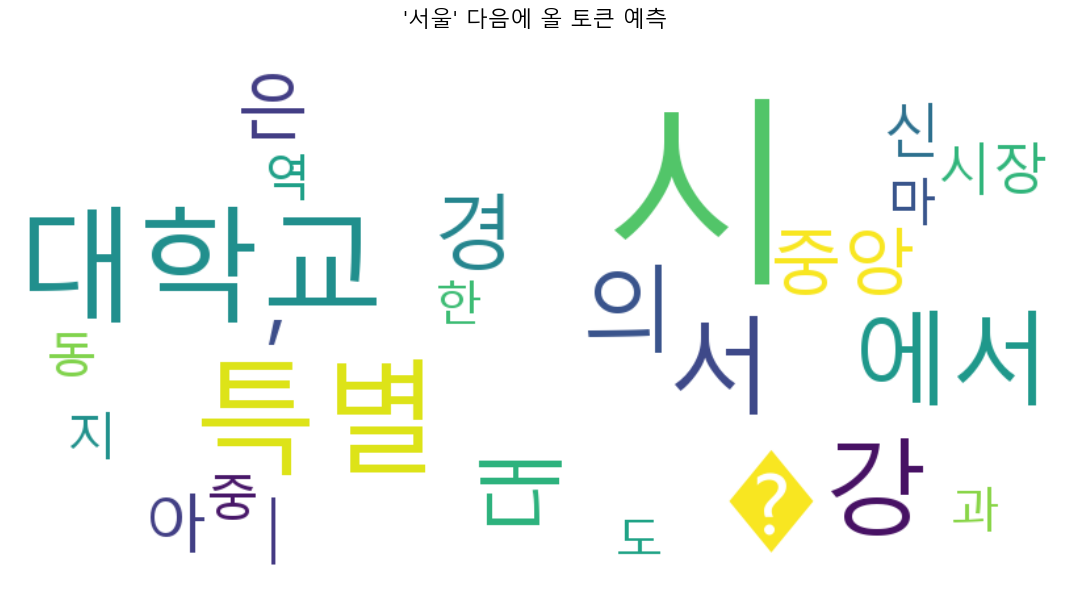

In [7]:
# 워드클라우드 생성 테스트
input_word = "서울"
visualize_next_tokens(model=model, tokenizer=tokenizer, text=input_word, n=30)